In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pmdarima as pm




from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [9]:
df = pd.read_csv("sensor-fault-detection.csv")
df = df[:5000]

In [10]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [11]:
df = df.sort_values(by="Timestamp")
df = df.reset_index(drop=True)

In [12]:
df["Value"] = pd.to_numeric(df["Value"])

In [13]:
df.describe()

,Value
count,5000.000000
mean,24.195869
std,5.471880
min,6.886155
25%,21.273069
50%,24.453760
75%,27.540283
max,149.601822


In [18]:
display(df.head())

,Timestamp,Value
0,2016-08-01 03:00:00+03:00,27.154348
1,2016-08-01 04:00:00+03:00,26.768456
2,2016-08-01 16:00:00+03:00,27.250818
3,2016-08-01 19:00:00+03:00,28.119251
4,2016-08-01 21:00:00+03:00,28.698278


In [19]:
train = df["Value"][:-int(0.2*len(df))]
test = df["Value"][-int(0.2*len(df)):]
train_df = df[:-int(0.2*len(df))]
test_df = df[-int(0.2*len(df)):]
time_stamps = int(0.2*len(df))+1

In [20]:
baseline_model = NaiveForecaster(strategy="mean")
baseline_model.fit(train)
y_pred = baseline_model.predict(fh=[i for i in range(1,time_stamps)])

In [21]:
prediction = pd.DataFrame({"Value":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

In [22]:
display(prediction)

,Value,Timestamp
4000,23.762066,2017-07-18 10:10:00+03:00
4001,23.762066,2017-07-18 10:25:00+03:00
4002,23.762066,2017-07-18 13:15:00+03:00
4003,23.762066,2017-07-18 13:55:00+03:00
4004,23.762066,2017-07-18 14:30:00+03:00
...,...,...
4995,23.762066,2017-08-31 18:35:00+03:00
4996,23.762066,2017-08-31 19:35:00+03:00
4997,23.762066,2017-08-31 19:55:00+03:00
4998,23.762066,2017-08-31 20:10:00+03:00


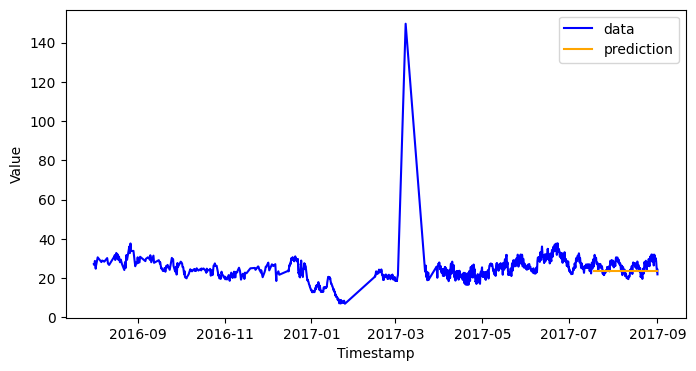

In [23]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Value",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Value",color="orange",label="prediction")
plt.show()

In [24]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 3.0148912683697278
RMSE: 3.644600181033238
MAPE: 0.11151411147424273


# Using a more sophisticated model (ARIMA) and computing the performence metrics

In [29]:
model_arima = ARIMA(train,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
prediction = pd.DataFrame({"Value":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

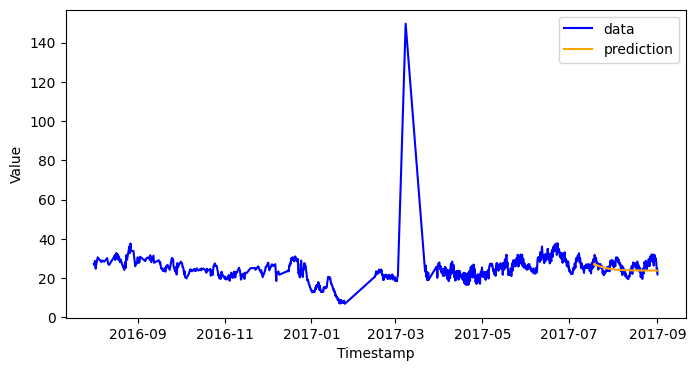

In [31]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Value",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Value",color="orange",label="prediction")
plt.show()

In [32]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 2.7217607426304875
RMSE: 3.3501629702619526
MAPE: 0.10185784525940113


# Testing a different refinement method each time and looking at the performence

* The Box Cox

In [33]:
train_BoxCox, lam = boxcox(train)
model_arima = ARIMA(train_BoxCox,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))
y_pred = inv_boxcox(y_pred,lam)

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [35]:
prediction = pd.DataFrame({"Value":y_pred})
prediction.index = range(4000,4000+len(prediction))
prediction["Timestamp"] = test_df["Timestamp"]

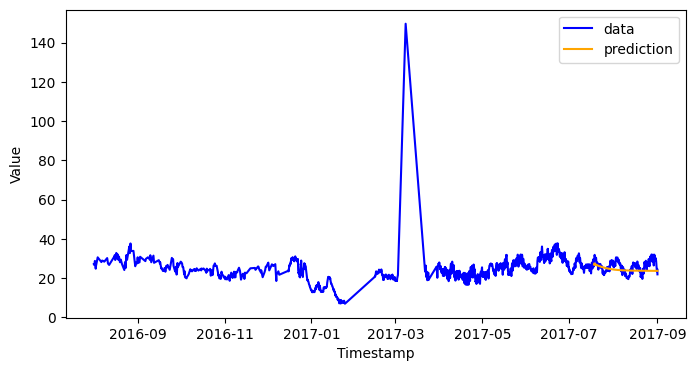

In [36]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Value",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Value",color="orange",label="prediction")
plt.show()

In [37]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 2.76177756789895
RMSE: 3.4055288060302575
MAPE: 0.10309655458929687


* IQR impuration with the median

In [38]:
median = np.median(train)
train_IQR = train.copy()
for i in range(len(train_IQR)):
    if train_IQR[i]>1.5*median:
        train_IQR[i] = median
        

In [39]:
model_arima = ARIMA(train_IQR,order=(20,0,20))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [40]:
prediction = pd.DataFrame({"Value":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

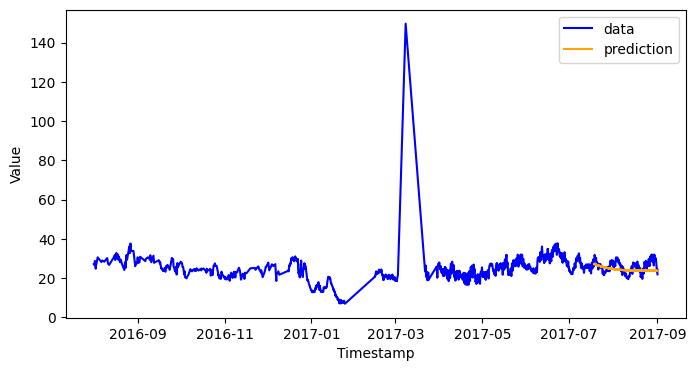

In [41]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Value",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Value",color="orange",label="prediction")
plt.show()

In [ ]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 24.2332069156856
RMSE: 44.383038585956804
MAPE: 0.044538853385563085


* Fourier Trend

In [42]:
df_fourier = df.copy()

In [51]:
t = np.arange(len(df_fourier))
my_range = [i/10 for i in range(100)]
for value in my_range:
    for order in range(1,10):
        df_fourier[f"fourier_sin_order_{order}"] = np.sin(2* np.pi * order * t*value)
        df_fourier[f"fourier_cos_order_{order}"] = np.cos(2* np.pi * order * t*value)
    
fourier_features = [i for i in list(df_fourier) if i.startswith("fourier")]
train_df_fourier = df_fourier[:-int(0.2*len(df))]
test_df_fourier = df_fourier[-int(0.2*len(df)):]

In [52]:
model = pm.auto_arima(
    train_df_fourier["Value"],
    X = train_df_fourier[fourier_features],
    seasonal = False,
    stepwise = True,
    suppress_warnings = True,
    max_order = None,
    information_criterion = "aicc",
    error_action = "ignore"
)
y_pred = model.predict(n_periods = len(test_df_fourier), X=test_df_fourier[fourier_features])

In [53]:
prediction = pd.DataFrame({"Value":y_pred})
prediction["Timestamp"] = test_df["Timestamp"]

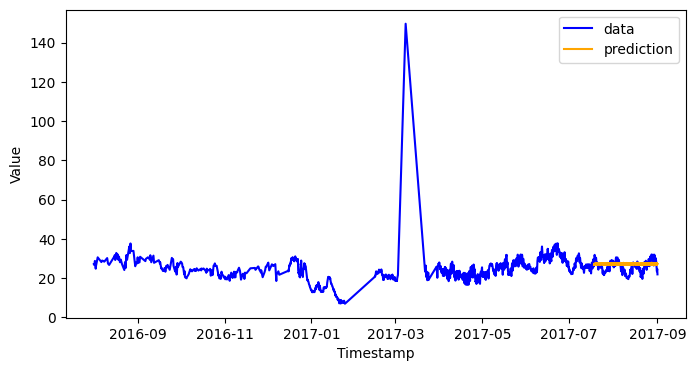

In [ ]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_fourier,x="Timestamp",y="Value",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Value",color="orange",label="prediction")
plt.show()

In [61]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 2.55029236904647
RMSE: 3.166154236884507
MAPE: 0.10548663783548583


* Seasonal Differencing

In [85]:
df_diff = df.diff()
train_diff = df["Value"][:-int(0.2*len(df))]
test_diff = df["Value"][-int(0.2*len(df)):]

train_diff.dropna(inplace=True)
base = df.iloc[int(-len(df)*0.2)-1].loc["Value"]

In [86]:
train_diff = df_diff["Value"]

In [87]:
model_arima = ARIMA(train_diff,order=(20,0,20))
model_arima = model_arima.fit()
y_pred_diff = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [88]:
y_pred_diff = list(y_pred_diff)

In [89]:
y_pred = [y_pred_diff[0]+base]
for i in range(1,len(test)):
    y_pred.append(y_pred_diff[i]+y_pred[-1])

In [90]:
prediction = pd.DataFrame({"Value":y_pred})
prediction.index = range(4000,4000+len(test))
prediction["Timestamp"] = test_df["Timestamp"]


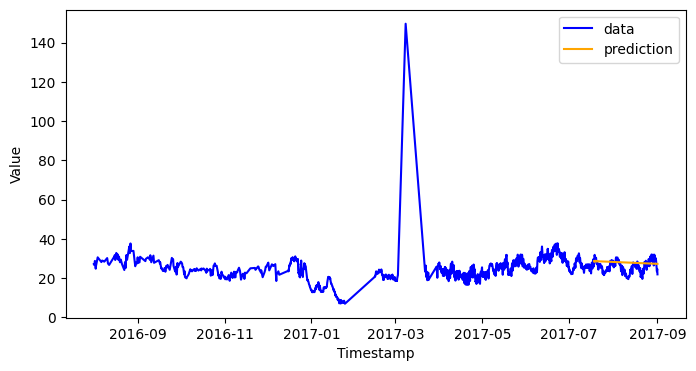

In [91]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Timestamp",y="Value",color="blue",label="data")
sns.lineplot(data=prediction,x="Timestamp",y="Value",color="orange",label="prediction")
plt.show()

In [92]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 2.909767025191967
RMSE: 3.578507141811104
MAPE: 0.1215605256670635
